<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Projet4_MNIST_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Unsupervised Learning Project
Apply K-Means, PCA and t-SNE on MNIST dataset.

In [17]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [18]:
# =========================
# 2. Load Dataset
# =========================
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("Shape:", X.shape)

Shape: (1797, 64)


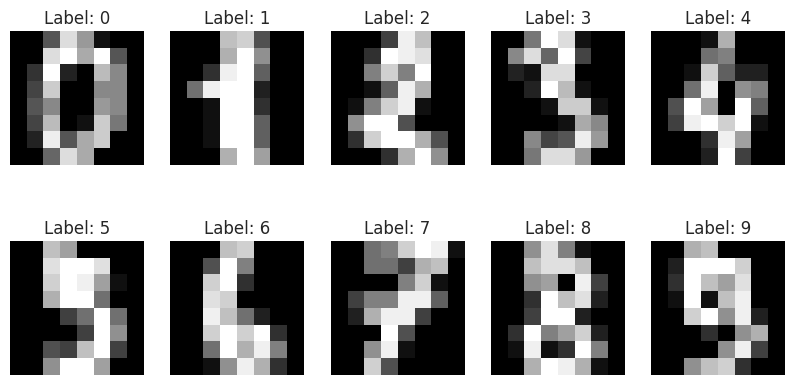

In [19]:
# =========================
# 3. Visualize Sample Images
# =========================
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8,8), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')

plt.show()

In [20]:
# 4. Normalize Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

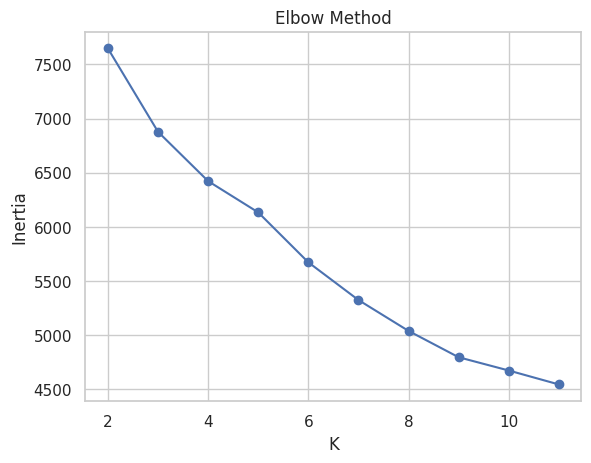

In [21]:
# 5. Elbow Method
inertia = []
for k in range(2,12):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(2,12), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

In [22]:
# 6. Train KMeans (K=10)
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

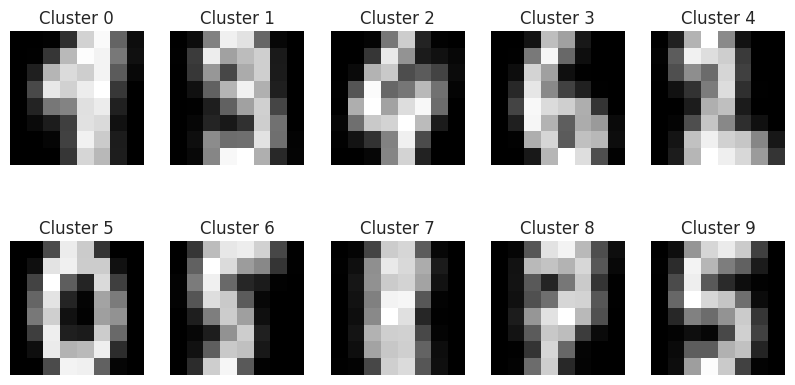

In [23]:
# =========================
# 7. Visualize Centroids
# =========================
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(centroids[i].reshape(8,8), cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off')

plt.show()

In [24]:
# 8. Silhouette Score
score = silhouette_score(X_scaled[:10000], clusters[:10000])
print('Score:', score)

Score: 0.18453279438835046


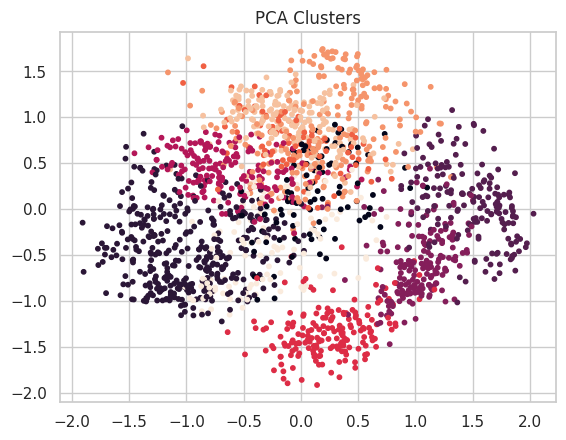

In [25]:
# 9. PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled[:5000])
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters[:5000], s=10)
plt.title('PCA Clusters')
plt.show()

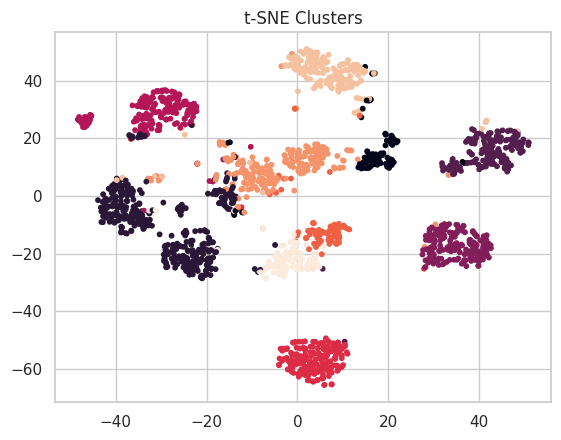

In [26]:
# 10. t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled[:2000])
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters[:2000], s=10)
plt.title('t-SNE Clusters')
plt.show()